In [50]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv('cars.csv', encoding='latin1')

In [52]:
df.head(10)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
5,BMW,Mclaren 720s,V8,"3,994 cc",710 hp,341 km/h,2.9 sec,"$499,000",Petrol,2,770 Nm
6,ASTON MARTIN,VANTAGE F1,V8,"3,982 cc",656 hp,314 km/h,3.6 sec,"$193,440",Petrol,2,685 Nm
7,BENTLEY,Continental GT Azure,V8,"3,996 cc",550 hp,318 km/h,4.0 sec,"$311,000",Petrol,4,900 Nm
8,LAMBORGHINI,VENENO ROADSTER,V12,"6,498 cc",750 hp,356 km/h,2.9 sec,"$4,500,000",Petrol,2,690 Nm
9,FERRARI,F8 TRIBUTO,V8,"3,900 cc",710 hp,340 km/h,2.9 sec,"$280,000",Petrol,2,770 Nm


Choosing Metrics for Clusters

In [53]:
clustering_metrics = ['HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H']

In [54]:
profiling_features = ['Company Names', 'Cars Names', 'Engines', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque']

In [55]:
df_subset = df[clustering_metrics + profiling_features].copy()

In [56]:
df_subset.head()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Company Names,Cars Names,Engines,Cars Prices,Fuel Types,Seats,Torque
0,963 hp,340 km/h,2.5 sec,FERRARI,SF90 STRADALE,V8,"$1,100,000",plug in hyrbrid,2,800 Nm
1,563 hp,250 km/h,5.3 sec,ROLLS ROYCE,PHANTOM,V12,"$460,000",Petrol,5,900 Nm
2,70-85 hp,165 km/h,10.5 sec,Ford,KA+,1.2L Petrol,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,630 hp,250 km/h,3.2 sec,MERCEDES,GT 63 S,V8,"$161,000",Petrol,4,900 Nm
4,602 hp,320 km/h,3.6 sec,AUDI,AUDI R8 Gt,V10,"$253,290",Petrol,2,560 Nm


Data Cleaning and Scaling

In [57]:
df_subset['HorsePower'] = df_subset['HorsePower'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [58]:
df_subset['Total Speed'] = df_subset['Total Speed'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [59]:
df_subset['Performance(0 - 100 )KM/H'] = df_subset['Performance(0 - 100 )KM/H'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [60]:
df_clean = df_subset.dropna(subset=clustering_metrics).copy()

In [61]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[clustering_metrics])

In [62]:
df_scaled = pd.DataFrame(scaled_values, columns=clustering_metrics, index=df_clean.index)

In [63]:
df_final = pd.concat([df_scaled, df_clean[profiling_features]], axis=1)

In [64]:
df_final.head()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Company Names,Cars Names,Engines,Cars Prices,Fuel Types,Seats,Torque
0,3.015819,2.337117,-1.530418,FERRARI,SF90 STRADALE,V8,"$1,100,000",plug in hyrbrid,2,800 Nm
1,1.193722,0.629632,-0.684151,ROLLS ROYCE,PHANTOM,V12,"$460,000",Petrol,5,900 Nm
2,-1.052013,-0.982994,0.887488,Ford,KA+,1.2L Petrol,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,1.498923,0.629632,-1.318851,MERCEDES,GT 63 S,V8,"$161,000",Petrol,4,900 Nm
4,1.371376,1.957676,-1.197956,AUDI,AUDI R8 Gt,V10,"$253,290",Petrol,2,560 Nm


Similarity Measurement

In [65]:
distance_matrix = euclidean_distances(df_scaled)

In [66]:
euclidean_similarity = 1 / (1 + distance_matrix)

Top High-performance Cars Similar to Ferrari 812 GTS

In [67]:
car_index = 10
car_name = df_final.iloc[car_index]['Cars Names']

In [68]:
similar_scores = list(enumerate(euclidean_similarity[car_index]))
similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

In [69]:
print(f"\n--- Top 10 Cars Most Similar to: {car_name} ---")
for i in range(1, 11):
    match_index = similar_scores[i][0]
    match_score = similar_scores[i][1]
    match_company = df_final.iloc[match_index]['Company Names']
    match_model = df_final.iloc[match_index]['Cars Names']

    print(f"{match_company}: {match_model}: {match_score * 100:.1f}%")


--- Top 10 Cars Most Similar to: 812 GTS ---
FERRARI: MONZA SP2: 100.0%
LAMBORGHINI: AVENTADOR SVJ ROADSTER: 81.0%
LAMBORGHINI: AVENTADOR SVJ XAGO: 81.0%
LAMBORGHINI: SIAN: 80.9%
LAMBORGHINI: AVENTADOR SVJ: 80.9%
LAMBORGHINI: AVENTADOR S: 77.3%
LAMBORGHINI: AVENTADOR SV: 77.3%
LAMBORGHINI: AVENTADOR ULTIMAE: 76.9%
LAMBORGHINI: AVENTADOR LP 780-4 ULTIMATE: 76.9%
LAMBORGHINI: AVENTADOR LP 780-4 ULTIMATE ROADSTER: 76.9%


Top Low-Performance Cars Similar to Nissan Sentra

In [70]:
car_index = 27
car_company = df_final.iloc[car_index]['Company Names']
car_name = df_final.iloc[car_index]['Cars Names']

In [71]:
similar_scores = list(enumerate(euclidean_similarity[car_index]))
similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

In [72]:
print(f"\n--- Top 10 Cars Most Similar to: {car_company} {car_name} ---")
for i in range(1, 11):
    match_index = similar_scores[i][0]
    match_score = similar_scores[i][1]
    match_company = df_final.iloc[match_index]['Company Names']
    match_model = df_final.iloc[match_index]['Cars Names']

    print(f"{match_company}: {match_model}: {match_score * 100:.1f}%")


--- Top 10 Cars Most Similar to: NISSAN SENTRA ---
Volkswagen: Sharan Business: 97.0%
HYUNDAI: Tiburon: 95.2%
HYUNDAI: Elantra GT: 94.5%
Volkswagen: Jetta SportWagen: 91.6%
HONDA: CIVIC: 90.9%
TOYOTA: CELICA: 90.9%
Peugeot: 308: 90.5%
Peugeot: e-2008 GT: 90.2%
Mazda: Familia Astina: 90.0%
Volkswagen: Taos: 86.8%


Top Medium-Performance Cars Similar to Toyota Sequoia

In [73]:
car_index = 21
car_name = df_final.iloc[car_index]['Cars Names']

In [74]:
similar_scores = list(enumerate(euclidean_similarity[car_index]))
similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

In [75]:
print(f"\n--- Top 10 Cars Most Similar to: {car_name} ---")
for i in range(1, 11):
    match_index = similar_scores[i][0]
    match_score = similar_scores[i][1]
    match_company = df_final.iloc[match_index]['Company Names']
    match_model = df_final.iloc[match_index]['Cars Names']

    print(f"{match_company}: {match_model}: {match_score * 100:.1f}%")


--- Top 10 Cars Most Similar to: TOYOTA SEQUOIA ---
Nissan: Titan XD: 88.6%
Nissan: Pathfinder Armada: 87.1%
Nissan: Patrol Black Edition: 87.1%
GMC: Yukon XL: 84.9%
Chevrolet: Suburban High Country: 84.7%
Chevrolet: Tahoe Premier: 84.7%
Chevrolet: Tahoe Sport Edition: 84.7%
GMC: Yukon Denali: 84.7%
Chevrolet: Tahoe High Country: 84.2%
GMC: Yukon XL Denali Ultimate: 84.2%


KMeans and Elbow Curve

In [76]:
inertia_values = []
K_range = range(1, 11)

In [77]:
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(df_scaled)
    
    inertia_values.append(kmeans_test.inertia_)

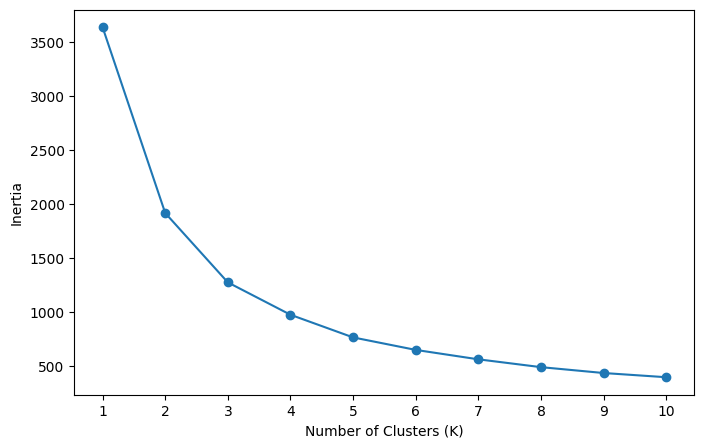

In [78]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

Label Generation

In [79]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = final_kmeans.fit_predict(df_scaled)

In [80]:
df_final = df_final.reset_index(drop=True)

In [81]:
display(df_final.head(10))

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Company Names,Cars Names,Engines,Cars Prices,Fuel Types,Seats,Torque,Cluster
0,3.015819,2.337117,-1.530418,FERRARI,SF90 STRADALE,V8,"$1,100,000",plug in hyrbrid,2,800 Nm,1
1,1.193722,0.629632,-0.684151,ROLLS ROYCE,PHANTOM,V12,"$460,000",Petrol,5,900 Nm,1
2,-1.052013,-0.982994,0.887488,Ford,KA+,1.2L Petrol,"$12,000-$15,000",Petrol,5,100 - 140 Nm,0
3,1.498923,0.629632,-1.318851,MERCEDES,GT 63 S,V8,"$161,000",Petrol,4,900 Nm,1
4,1.371376,1.957676,-1.197956,AUDI,AUDI R8 Gt,V10,"$253,290",Petrol,2,560 Nm,1
5,1.863343,2.356090,-1.409523,BMW,Mclaren 720s,V8,"$499,000",Petrol,2,770 Nm,1
6,1.617359,1.843844,-1.197956,ASTON MARTIN,VANTAGE F1,V8,"$193,440",Petrol,2,685 Nm,1
7,1.134504,1.919732,-1.077061,BENTLEY,Continental GT Azure,V8,"$311,000",Petrol,4,900 Nm,1
8,2.045552,2.640671,-1.409523,LAMBORGHINI,VENENO ROADSTER,V12,"$4,500,000",Petrol,2,690 Nm,1
9,1.863343,2.337117,-1.409523,FERRARI,F8 TRIBUTO,V8,"$280,000",Petrol,2,770 Nm,1


Create Nodes and Edges

In [82]:
import networkx as nx
G = nx.Graph()

In [83]:
for i, row in df_final.iterrows():
    G.add_node(i,
               car_name=str(row['Cars Names']),
               cluster=int(row['Cluster']))

In [84]:
THRESHOLD = 0.8
num_cars = len(df_final)

In [85]:
for i in range(num_cars):
    for j in range(i + 1, num_cars):
        sim_score = euclidean_similarity[i][j]
        if sim_score >= THRESHOLD:
            G.add_edge(i, j, weight=float(sim_score))

In [86]:
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Nodes: 1212
Edges: 15120


In [87]:
export_filename = "car_clusters.gexf"
nx.write_gexf(G, export_filename)

Data Cleaning (continued)

In [88]:
import numpy as np

def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
        
    # Remove $ and commas
    price_str = str(price_str).replace('$', '').replace(',', '')
    
    # Calculate the average for price range estimated
    if '-' in price_str:
        low, high = price_str.split('-')
        return (float(low) + float(high)) / 2
    
    try:
        return float(price_str)
    except:
        return np.nan
    
df_final['Cars Prices Cleaned'] = df_final['Cars Prices'].apply(clean_price)

In [89]:
columns_to_keep = ['Engines', 'Cars Prices Cleaned', 'Seats', 'Torque', 'Cluster']
df_model = df_final[columns_to_keep].copy()

In [90]:
def clean_torque(torque_str):
    if pd.isna(torque_str):
        return np.nan
        
    # Remove 'Nm' and strip extra spaces
    torque_str = str(torque_str).replace('Nm', '').replace(' ', '')
    
    # Calculate the average of torque range
    if '-' in torque_str:
        try:
            low, high = torque_str.split('-')
            return (float(low) + float(high)) / 2
        except:
            return np.nan
            
    try:
        return float(torque_str)
    except:
        return np.nan

In [91]:
df_model['Torque Cleaned'] = df_model['Torque'].apply(clean_torque)
df_model = df_model.drop(columns=['Torque'])

In [92]:
def clean_seats(seat_val):
    if pd.isna(seat_val):
        return np.nan
        
    seat_str = str(seat_val).strip()
    
    if '+' in seat_str:
        try:
            parts = seat_str.split('+')
            return sum(float(p) for p in parts)
        except:
            return np.nan
    
    try:
        return float(seat_str)
    except:
        return np.nan

In [93]:
df_model['Seats'] = df_model['Seats'].apply(clean_seats)
# Fill missing values with the meadian seat count
df_model['Seats'] = df_model['Seats'].fillna(df_model['Seats'].median())

In [94]:
display(df_model.head(10))

,Engines,Cars Prices Cleaned,Seats,Cluster,Torque Cleaned
0,V8,1100000.0,2.0,1,800.0
1,V12,460000.0,5.0,1,900.0
2,1.2L Petrol,13500.0,5.0,0,120.0
3,V8,161000.0,4.0,1,900.0
4,V10,253290.0,2.0,1,560.0
5,V8,499000.0,2.0,1,770.0
6,V8,193440.0,2.0,1,685.0
7,V8,311000.0,4.0,1,900.0
8,V12,4500000.0,2.0,1,690.0
9,V8,280000.0,2.0,1,770.0


In [95]:
# The top 10 most common engine types in dataset
top_10_engines = df_final['Engines'].value_counts().head(10).index

# Group rare engines
def group_engines(engine_name):
    if engine_name in top_10_engines:
        return engine_name
    else:
        return 'Other'

df_model['Engines Grouped'] = df_final['Engines'].apply(group_engines)

df_model = df_model.drop(columns=['Engines'])

df_model = pd.get_dummies(df_model, columns=['Engines Grouped'], drop_first=True)

In [96]:
display(df_model.head())

,Cars Prices Cleaned,Seats,Cluster,Torque Cleaned,Engines Grouped_2.0L Inline-4,Engines Grouped_5.6L V8,Engines Grouped_Dual Electric Motors,Engines Grouped_Electric Motor,Engines Grouped_I4,Engines Grouped_Inline-4,Engines Grouped_Other,Engines Grouped_V12,Engines Grouped_V6,Engines Grouped_V8
0,1100000.0,2.0,1,800.0,False,False,False,False,False,False,False,False,False,True
1,460000.0,5.0,1,900.0,False,False,False,False,False,False,False,True,False,False
2,13500.0,5.0,0,120.0,False,False,False,False,False,False,True,False,False,False
3,161000.0,4.0,1,900.0,False,False,False,False,False,False,False,False,False,True
4,253290.0,2.0,1,560.0,False,False,False,False,False,False,True,False,False,False


Data Split

In [97]:
from sklearn.model_selection import train_test_split

y = df_model['Cluster']
X = df_model.drop(columns=['Cluster'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Original dataset: {X.shape[0]} rows")
print(f"Training features (X_train): {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Testing features (X_test): {X_test.shape[0]} rows, {X_test.shape[1]} columns")

Original dataset: 1212 rows
Training features (X_train): 969 rows, 13 columns
Testing features (X_test): 243 rows, 13 columns


Random Forest Classifier 

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [99]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [100]:
predictions = rf_model.predict(X_test)

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78        72
           1       0.95      0.87      0.91        45
           2       0.85      0.90      0.87       126

    accuracy                           0.85       243
   macro avg       0.87      0.84      0.85       243
weighted avg       0.85      0.85      0.85       243



In [108]:
print("Top 5 Engines in Cluster 1 (High Performance):")
hypercar_engines = df_final[df_final['Cluster'] == 1]['Engines'].value_counts().head(5)
print(hypercar_engines)

Top 5 Engines in Cluster 1 (High Performance):
Engines
V12                       51
V8                        30
3.0L Twin-Turbo Flat-6    15
V10                       11
8.0L Quad-Turbo W16       10
Name: count, dtype: int64


In [109]:
print("Top 5 Engines in Cluster 0 (Economy):")
economy_engines = df_final[df_final['Cluster'] == 0]['Engines'].value_counts().head(5)
print(economy_engines)

Top 5 Engines in Cluster 0 (Economy):
Engines
1.6L Inline-4      19
Inline-4           19
2.0L Inline-4      17
2.0L 4-Cylinder    11
1.8L Inline-4      10
Name: count, dtype: int64


In [110]:
print("Top 5 Engines in Cluster 2 (Premium Economy):")
premium_engines = df_final[df_final['Cluster'] == 2]['Engines'].value_counts().head(5)
print(premium_engines)

Top 5 Engines in Cluster 2 (Premium Economy):
Engines
I4                  55
V6                  37
Inline-4            19
5.6L V8             17
5.3L V8 Gasoline    16
Name: count, dtype: int64


Feature Analysis

In [112]:
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

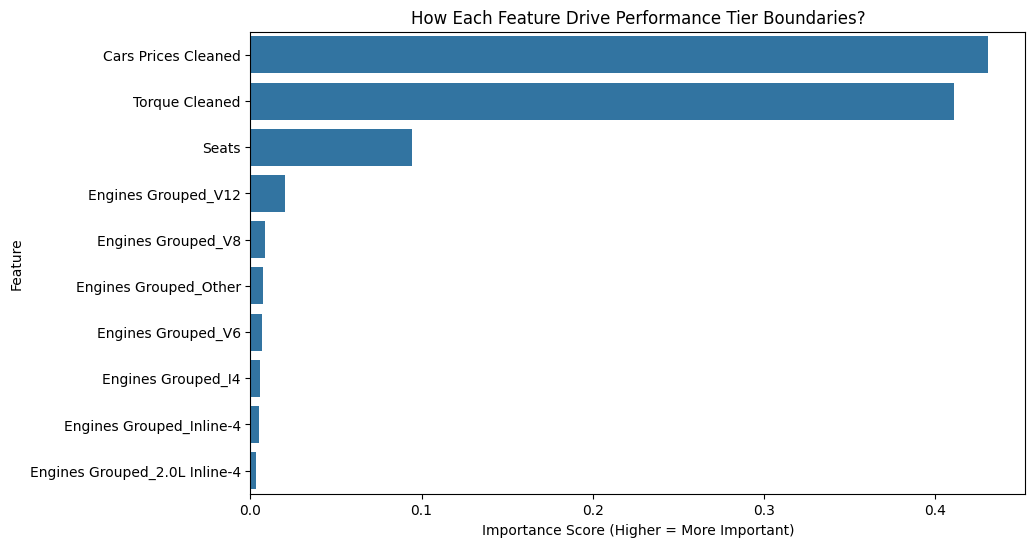

In [115]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('How Each Feature Drive Performance Tier Boundaries?')
plt.xlabel('Importance Score (Higher = More Important)')
plt.ylabel('Feature')
plt.show()